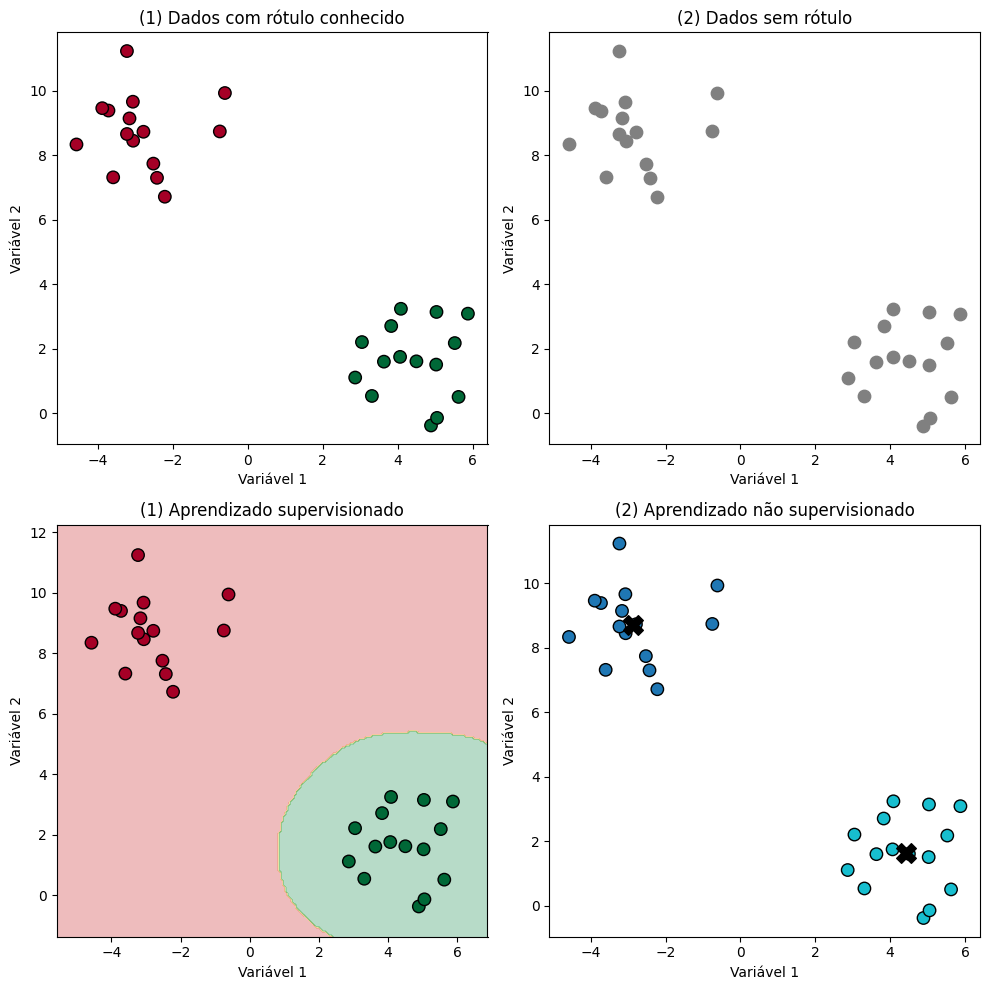

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.svm import SVC

# -----------------------------
# Gerar dados sintéticos
# -----------------------------
X, y = make_blobs(n_samples=30, centers=2, cluster_std=1.2, random_state=42)

# -----------------------------
# 1. Dados sem rótulo (não supervisionado)
# -----------------------------
# Esses são os dados crus, sem informação de classe

# -----------------------------
# 2. Dados com rótulo (supervisionado)
# -----------------------------
# Aqui usamos os rótulos verdadeiros do make_blobs

# -----------------------------
# 3. Classificação supervisionada
# -----------------------------
clf = SVC(kernel='rbf', gamma=0.5, probability=True)
clf.fit(X, y)

# Grade para plotar as regiões de decisão
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# -----------------------------
# 4. Clusterização (não supervisionado)
# -----------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

# -----------------------------
# Plotagem
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.ravel()

# 1. Dados sem rótulo
axs[1].scatter(X[:, 0], X[:, 1], c='gray', s=80)
axs[1].set_title("(2) Dados sem rótulo")
axs[1].set_xlabel("Variável 1")
axs[1].set_ylabel("Variável 2")

# 2. Dados com rótulo (supervisionado)
axs[0].scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', s=80, edgecolor='k')
axs[0].set_title("(1) Dados com rótulo conhecido")
axs[0].set_xlabel("Variável 1")
axs[0].set_ylabel("Variável 2")

# 3. Classificação supervisionada (regiões)
axs[2].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
axs[2].scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', s=80, edgecolor='k')
axs[2].set_title("(1) Aprendizado supervisionado")
axs[2].set_xlabel("Variável 1")
axs[2].set_ylabel("Variável 2")

# 4. Clusterização (K-means)
axs[3].scatter(X[:, 0], X[:, 1], c=clusters, cmap='tab10', s=80, edgecolor='k')
centroids = kmeans.cluster_centers_
axs[3].scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X')
axs[3].set_title("(2) Aprendizado não supervisionado")
axs[3].set_xlabel("Variável 1")
axs[3].set_ylabel("Variável 2")

plt.tight_layout()
plt.show()
